In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

df_fitur_clean = pd.read_csv("../data/manifest_fitur.csv")
feature_cols = ["contrast", "correlation", "energy", "homogeneity", "hue", "saturation", "value"]
X = df_fitur_clean[feature_cols].values
y = df_fitur_clean["label"].values

scaler = joblib.load("../models/scaler.joblib")
X_scaled = scaler.transform(X)

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print("Jumlah data train:", X_train.shape[0])
print("Jumlah data test :", X_test.shape[0])
print("\nDistribusi label di data train:")
print(pd.Series(y_train).value_counts())
print("\nDistribusi label di data test:")
print(pd.Series(y_test).value_counts())

Jumlah data train: 188
Jumlah data test : 47

Distribusi label di data train:
sehat             117
terkontaminasi     71
Name: count, dtype: int64

Distribusi label di data test:
sehat             29
terkontaminasi    18
Name: count, dtype: int64


In [3]:
model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"Akurasi di data train: {train_acc:.4f}")
print(f"Akurasi di data test : {test_acc:.4f}")

Akurasi di data train: 0.9309
Akurasi di data test : 0.9149


In [4]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=["sehat", "terkontaminasi"])
print("Confusion Matrix:")
print("                  Prediksi Sehat  Prediksi Terkontaminasi")
print(f"Aktual Sehat           {cm[0][0]:^10}        {cm[0][1]:^10}")
print(f"Aktual Terkontaminasi  {cm[1][0]:^10}        {cm[1][1]:^10}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=["sehat", "terkontaminasi"]))

Confusion Matrix:
                  Prediksi Sehat  Prediksi Terkontaminasi
Aktual Sehat               26                3     
Aktual Terkontaminasi      1                 17    

Classification Report:
                precision    recall  f1-score   support

         sehat       0.96      0.90      0.93        29
terkontaminasi       0.85      0.94      0.89        18

      accuracy                           0.91        47
     macro avg       0.91      0.92      0.91        47
  weighted avg       0.92      0.91      0.92        47



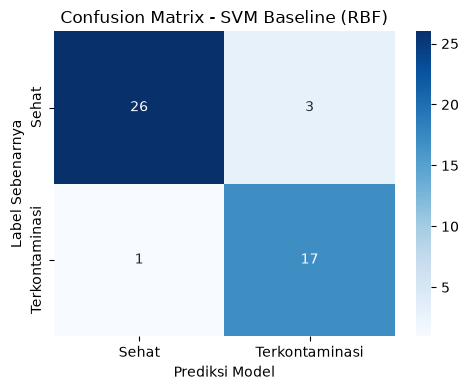

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../results", exist_ok=True)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Sehat", "Terkontaminasi"],
    yticklabels=["Sehat", "Terkontaminasi"],
    ax=ax
)
ax.set_xlabel("Prediksi Model")
ax.set_ylabel("Label Sebenarnya")
ax.set_title("Confusion Matrix - SVM Baseline (RBF)")
plt.tight_layout()
plt.savefig("../results/confusion_matrix_baseline.png", dpi=150)
plt.show()

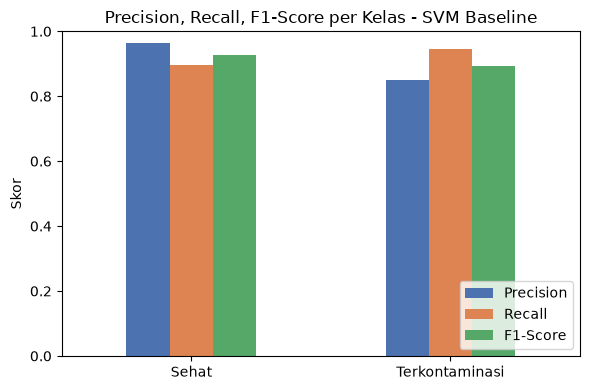

In [6]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=["sehat", "terkontaminasi"]
)

metrics_df = pd.DataFrame({
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}, index=["Sehat", "Terkontaminasi"])

fig, ax = plt.subplots(figsize=(6, 4))
metrics_df.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylim(0, 1)
ax.set_ylabel("Skor")
ax.set_title("Precision, Recall, F1-Score per Kelas - SVM Baseline")
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/metrics_baseline.png", dpi=150)
plt.show()

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Kombinasi parameter terbaik:")
print(grid_search.best_params_)
print(f"\nSkor F1-macro terbaik (rata-rata cross-validation): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
train_acc_tuned = best_model.score(X_train, y_train)
test_acc_tuned = best_model.score(X_test, y_test)

print(f"\nAkurasi model tuned di data train: {train_acc_tuned:.4f}")
print(f"Akurasi model tuned di data test : {test_acc_tuned:.4f}")

Kombinasi parameter terbaik:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

Skor F1-macro terbaik (rata-rata cross-validation): 0.8864

Akurasi model tuned di data train: 0.9415
Akurasi model tuned di data test : 0.9574


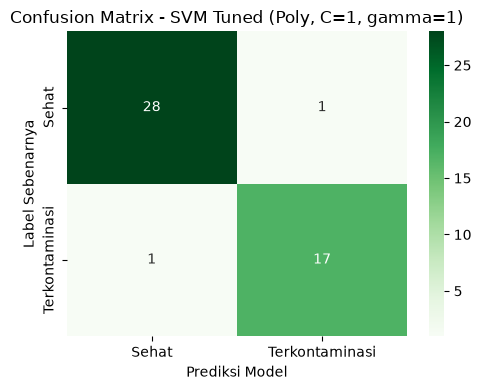

                precision    recall  f1-score   support

         sehat       0.97      0.97      0.97        29
terkontaminasi       0.94      0.94      0.94        18

      accuracy                           0.96        47
     macro avg       0.95      0.95      0.95        47
  weighted avg       0.96      0.96      0.96        47



In [8]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=["sehat", "terkontaminasi"])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_tuned, annot=True, fmt='d', cmap='Greens',
    xticklabels=["Sehat", "Terkontaminasi"],
    yticklabels=["Sehat", "Terkontaminasi"],
    ax=ax
)
ax.set_xlabel("Prediksi Model")
ax.set_ylabel("Label Sebenarnya")
ax.set_title("Confusion Matrix - SVM Tuned (Poly, C=1, gamma=1)")
plt.tight_layout()
plt.savefig("../results/confusion_matrix_tuned.png", dpi=150)
plt.show()

print(classification_report(y_test, y_pred_tuned, labels=["sehat", "terkontaminasi"]))

In [9]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

model_baseline = SVC(kernel='rbf', class_weight='balanced', random_state=42)
model_tuned = SVC(kernel='poly', C=1, gamma=1, class_weight='balanced', random_state=42)

scores_baseline = cross_val_score(model_baseline, X_scaled, y, cv=rskf, scoring='f1_macro')
scores_tuned = cross_val_score(model_tuned, X_scaled, y, cv=rskf, scoring='f1_macro')

print(f"Baseline (RBF)  - F1-macro rata-rata: {scores_baseline.mean():.4f} (+/- {scores_baseline.std():.4f})")
print(f"Tuned (Poly)    - F1-macro rata-rata: {scores_tuned.mean():.4f} (+/- {scores_tuned.std():.4f})")

Baseline (RBF)  - F1-macro rata-rata: 0.8757 (+/- 0.0429)
Tuned (Poly)    - F1-macro rata-rata: 0.8188 (+/- 0.0578)


In [10]:
final_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
final_model.fit(X_train, y_train)

joblib.dump(final_model, "../models/svm_model_v1.joblib")

print("Model final (RBF baseline) disimpan ke ../models/svm_model_v1.joblib")
print(f"Akurasi test: {final_model.score(X_test, y_test):.4f}")

Model final (RBF baseline) disimpan ke ../models/svm_model_v1.joblib
Akurasi test: 0.9149
